# Tarea 3: Redes Neuronales Multicapa (MLP)

Inteligencia Artificial — Universidad Diego Portales  
Integrantes: Maximiliano Oliva y Alonso Iturra

---

## Declaración de uso de herramientas de IA

En esta tarea se utilizaron herramientas de inteligencia artificial generativa con los siguientes propósitos específicos: generación de plantillas de código repetitivo y revisión de errores de sintaxis. Queda explícitamente declarado que todos los análisis, interpretaciones y conclusiones redactadas en celdas de texto son de autoría propia y no fueron generadas ni asistidas por ninguna herramienta de IA.

In [11]:
!pip install pandas numpy matplotlib scikit-learn torch torchvision

In [12]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 1. Dataset 1: posturas\_balanced\_50000.csv

### 1.1 Exploración inicial

El dataset corresponde a registros de posturas corporales capturados mediante sensores, donde cada fila describe la posición tridimensional de hasta siete puntos del cuerpo. La variable objetivo es Class, que toma valores del 1 al 5. A continuación se realiza una inspección preliminar del contenido.

In [13]:
df = pd.read_csv("datasets/postures_balanced_50000.csv")
print("Dimensiones:", df.shape)
print()
print("Distribución de clases:")
print(df['Class'].value_counts().sort_index().to_string())
print()
print("Porcentaje de valores faltantes por columna:")
print((df.isnull().sum() / len(df) * 100).round(2).to_string())

Dimensiones: (50000, 23)

Distribución de clases:
Class
1    10000
2    10000
3    10000
4    10000
5    10000

Porcentaje de valores faltantes por columna:
Class     0.00
User      0.00
X0        0.00
Y0        0.00
Z0        0.00
X1        0.00
Y1        0.00
Z1        0.00
X2        0.00
Y2        0.00
Z2        0.00
X3        0.83
Y3        0.83
Z3        0.83
X4        3.72
Y4        3.72
Z4        3.72
X5       15.85
Y5       15.85
Z5       15.85
X6       31.74
Y6       31.74
Z6       31.74


El dataset contiene 50.000 registros perfectamente balanceados, con exactamente 10.000 muestras por clase. Las variables de entrada son las coordenadas X, Y, Z de siete puntos corporales (columnas X0 a Z6), lo que resulta en 21 características numéricas continuas. La columna User identifica al sujeto que realizó la postura, por lo que se descarta como variable predictora para evitar fuga de información.

Se aprecia un patrón de valores faltantes que aumenta conforme el índice del punto sensor es mayor: los puntos X3 a Z3 tienen un 0.83 % de ausencias, X4 a Z4 un 3.72 %, X5 a Z5 un 15.85 % y X6 a Z6 un 31.74 %. Esto sugiere que algunos sujetos no tenían sensores en todos los puntos corporales durante la medición, lo cual es esperable en datos de captura de movimiento real.

In [14]:
# Descartamos el identificador de usuario
df_proc = df.drop(columns=['User'])
y_raw = df_proc['Class'].values
X_raw = df_proc.drop(columns=['Class']).values

# Imputación con la mediana: robusta ante la distribución asimétrica de coordenadas espaciales
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_raw)

# División estratificada 70 / 15 / 15
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_imp, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# Estandarización: se ajusta únicamente sobre el conjunto de entrenamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Tensores (clases 1-5 => índices 0-4 para CrossEntropyLoss)
to_t = lambda X: torch.tensor(X, dtype=torch.float32)
to_l = lambda y: torch.tensor(y - 1, dtype=torch.long)

BATCH = 256
train_loader = DataLoader(TensorDataset(to_t(X_train), to_l(y_train)), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(to_t(X_val),   to_l(y_val)),   batch_size=BATCH)
test_loader  = DataLoader(TensorDataset(to_t(X_test),  to_l(y_test)),  batch_size=BATCH)

IN, NC = X_train.shape[1], len(np.unique(y_raw))
print(f"Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}")
print(f"Entradas: {IN}   Clases: {NC}")

Train: 35,000  Val: 7,500  Test: 7,500
Entradas: 21   Clases: 5


La división 70/15/15 es una partición habitual en problemas de esta escala: el conjunto de entrenamiento es suficientemente grande para ajustar parámetros, mientras que validación y prueba tienen el mismo tamaño para que las comparaciones entre ellos sean simétricas. Al ser el dataset balanceado, la estratificación garantiza que cada subconjunto mantenga la proporción uniforme de clases.

La imputación por mediana se prefiere sobre la media cuando existen posibles valores extremos en coordenadas tridimensionales. El escalado estándar se calcula exclusivamente con el conjunto de entrenamiento y luego se aplica a validación y prueba, respetando el principio de que los conjuntos de evaluación no pueden influir en ningún paso del preprocesamiento.

In [15]:
IN, NC = 21, 5

class A1_Simple_Baseline(nn.Module):
    """Familia Simple/Baseline: una sola capa oculta de 32 neuronas con ReLU.
    Punto de referencia mínimo para verificar si el problema es linealmente separable."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(IN,32), nn.ReLU(), nn.Linear(32,NC))
    def forward(self, x): return self.net(x)

class A2_Simple_Tanh(nn.Module):
    """Familia Simple/Baseline: variante de A1 con activación Tanh.
    Permite comparar cómo se comporta una función saturante simétrica en datos centrados."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(IN,32), nn.Tanh(), nn.Linear(32,NC))
    def forward(self, x): return self.net(x)

class A3_Deep_Narrow(nn.Module):
    """Familia Profunda/Angosta: Input -> 32 -> 16 -> 8 -> Output.
    Explora abstracciones jerárquicas sin inflar el número de parámetros."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,32), nn.ReLU(),
            nn.Linear(32,16), nn.ReLU(),
            nn.Linear(16,8),  nn.ReLU(),
            nn.Linear(8,NC))
    def forward(self, x): return self.net(x)

class A4_Deep_BN(nn.Module):
    """Familia Profunda/Angosta: tres capas con Batch Normalization.
    Evalúa si la normalización interna mejora el flujo de gradientes en una red profunda."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32,16), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16,8),  nn.BatchNorm1d(8),  nn.ReLU(),
            nn.Linear(8,NC))
    def forward(self, x): return self.net(x)

class A5_Wide_Medium(nn.Module):
    """Familia Ancha/Capacidad Media: Input -> 128 -> 64 -> Output.
    Mayor capacidad por capa para capturar prototipos de posturas en alta dimensionalidad."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,128), nn.ReLU(),
            nn.Linear(128,64), nn.ReLU(),
            nn.Linear(64,NC))
    def forward(self, x): return self.net(x)

class A6_Wide_Large(nn.Module):
    """Familia Ancha/Capacidad Media: dos capas grandes.
    Variante de A5 con mayor ancho para estudiar el límite de capacidad antes de sobreajustar."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,256), nn.ReLU(),
            nn.Linear(256,128), nn.ReLU(),
            nn.Linear(128,NC))
    def forward(self, x): return self.net(x)

class A7_Regularized(nn.Module):
    """Familia Regularizada: Input -> 128 -> Dropout(0.3) -> 64 -> BN -> Output.
    Incluye Dropout y Batch Normalization para controlar el sobreajuste."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64,NC))
    def forward(self, x): return self.net(x)

class A8_Regularized_L2(nn.Module):
    """Familia Regularizada: misma topología que A7 pero sin Dropout/BN.
    La regularización se aplicará exclusivamente mediante weight decay (L2) en el optimizador."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IN,128), nn.ReLU(),
            nn.Linear(128,64), nn.ReLU(),
            nn.Linear(64,NC))
    def forward(self, x): return self.net(x)

arch_classes = [A1_Simple_Baseline, A2_Simple_Tanh, A3_Deep_Narrow, A4_Deep_BN,
                A5_Wide_Medium, A6_Wide_Large, A7_Regularized, A8_Regularized_L2]
arch_names   = ["A1-Simple_Baseline","A2-Simple_Tanh","A3-Deep_Narrow","A4-Deep_BN",
                "A5-Wide_Medium","A6-Wide_Large","A7-Regularized","A8-Regularized_L2"]
for n, cls in zip(arch_names, arch_classes):
    p = sum(x.numel() for x in cls().parameters())
    print(f"{n:<20}: {p:>7,} parámetros")

A1-Simple_Baseline  :     869 parámetros
A2-Simple_Tanh      :     869 parámetros
A3-Deep_Narrow      :   1,413 parámetros
A4-Deep_BN          :   1,525 parámetros
A5-Wide_Medium      :  11,397 parámetros
A6-Wide_Large       :  39,173 parámetros
A7-Regularized      :  11,525 parámetros
A8-Regularized_L2   :  11,397 parámetros


### 1.2 Justificación de las ocho arquitecturas

El problema consiste en clasificar posturas corporales a partir de 21 coordenadas tridimensionales. La entrada es de dimensionalidad moderada y el espacio de clases es reducido (5 categorías), lo que permite explorar un rango amplio de configuraciones sin tiempos de entrenamiento excesivos.

Partiendo de las cuatro familias clásicas sugeridas para un MLP de clasificación, se construyen ocho escenarios variando hiperparámetros dentro de cada familia. Esto permite identificar no solo qué familia es más adecuada, sino también qué variantes específicas dentro de ella aportan mayor ganancia.

Familia Simple/Baseline:
A1 implementa una sola capa oculta de 32 neuronas con ReLU, tal como se propone como referencia mínima. A2 conserva la misma topología pero cambia ReLU por Tanh, lo que permite observar si una función de activación simétrica se comporta mejor sobre coordenadas estandarizadas alrededor de cero.

Familia Profunda/Angosta:
A3 sigue la estructura sugerida de 32 → 16 → 8 neuronas, buscando abstracciones jerárquicas sin aumentar el número de parámetros. A4 añade Batch Normalization a esta misma estructura profunda para evaluar si la normalización estabiliza el entrenamiento y mejora la generalización.

Familia Ancha/Capacidad Media:
A5 utiliza exactamente la configuración 128 → 64 para explorar el aprendizaje mediante capas anchas. A6 amplía el ancho a 256 → 128 con el fin de estudiar si el problema se beneficia de mayor capacidad, o si esta produce sobreajuste inmediato.

Familia Regularizada:
A7 combina la arquitectura 128 → 64 con Dropout del 30 % y Batch Normalization, siguiendo la recomendación de regularizar redes con alta capacidad. A8 conserva la topología 128 → 64 pero delega toda la regularización al optimizador mediante weight decay, lo que permite comparar dos estrategias distintas sobre una misma estructura.

In [34]:
def train_model(model, train_loader, val_loader,
                epochs=80, lr=1e-3, weight_decay=0.0,
                patience=12, scheduler=False):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5) if scheduler else None

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss, no_improve, best_state = float('inf'), 0, None

    for epoch in range(epochs):
        model.train()
        tl, tc, tt = [], 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl.append(loss.item())
            tc += (out.argmax(1) == yb).sum().item(); tt += yb.size(0)

        model.eval()
        vl, vc, vt = [], 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vl.append(criterion(out, yb).item())
                vc += (out.argmax(1) == yb).sum().item(); vt += yb.size(0)

        history['train_loss'].append(np.mean(tl))
        history['val_loss'].append(np.mean(vl))
        history['train_acc'].append(tc/tt)
        history['val_acc'].append(vc/vt)
        if sched: sched.step()

        if history['val_loss'][-1] < best_val_loss:
            best_val_loss = history['val_loss'][-1]
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            model.load_state_dict(best_state)
            break

    if best_state: model.load_state_dict(best_state)
    return history, model

def get_predictions(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return np.array(trues), np.array(preds)

print("Funciones definidas.")

Funciones definidas.


In [17]:
configs = [
    {"name":"A1-Simple_Baseline", "cls":A1_Simple_Baseline, "lr":1e-3, "epochs":80,  "wd":0.0,   "sched":False},
    {"name":"A2-Simple_Tanh",   "cls":A2_Simple_Tanh,   "lr":5e-4, "epochs":80,  "wd":0.0,   "sched":False},
    {"name":"A3-Deep_Narrow",   "cls":A3_Deep_Narrow,   "lr":1e-3, "epochs":100, "wd":1e-5,  "sched":False},
    {"name":"A4-Deep_BN",       "cls":A4_Deep_BN,       "lr":1e-3, "epochs":100, "wd":1e-5,  "sched":False},
    {"name":"A5-Wide_Medium",   "cls":A5_Wide_Medium,   "lr":1e-3, "epochs":80,  "wd":1e-4,  "sched":False},
    {"name":"A6-Wide_Large",    "cls":A6_Wide_Large,    "lr":5e-4, "epochs":80,  "wd":1e-4,  "sched":True},
    {"name":"A7-Regularized",   "cls":A7_Regularized,   "lr":1e-3, "epochs":100, "wd":1e-4,  "sched":True},
    {"name":"A8-Regularized_L2","cls":A8_Regularized_L2,"lr":5e-4, "epochs":100, "wd":5e-3,  "sched":True},
]

results = {}
for cfg in configs:
    print(f"Entrenando {cfg['name']}...", end=" ")
    h, m = train_model(cfg['cls'](), train_loader, val_loader,
                       epochs=cfg['epochs'], lr=cfg['lr'],
                       weight_decay=cfg['wd'], scheduler=cfg['sched'])
    results[cfg['name']] = {'history': h, 'model': m}
    print(f"val_acc={max(h['val_acc']):.4f}  val_loss={min(h['val_loss']):.4f}")

Entrenando A1-Simple_Baseline... val_acc=0.9092  val_loss=0.2932
Entrenando A2-Simple_Tanh... val_acc=0.8684  val_loss=0.4039
Entrenando A3-Deep_Narrow... val_acc=0.9337  val_loss=0.2199
Entrenando A4-Deep_BN... val_acc=0.9524  val_loss=0.1578
Entrenando A5-Wide_Medium... val_acc=0.9617  val_loss=0.1415
Entrenando A6-Wide_Large... val_acc=0.9589  val_loss=0.1588
Entrenando A7-Regularized... val_acc=0.9715  val_loss=0.0960
Entrenando A8-Regularized_L2... val_acc=0.9332  val_loss=0.2469


In [18]:
rows = []
for name, res in results.items():
    h = res['history']
    rows.append({
        'Arquitectura':   name,
        'Val Acc (max)':  round(max(h['val_acc']),4),
        'Val Loss (min)': round(min(h['val_loss']),4),
        'Épocas':         len(h['val_loss'])
    })
df_cmp = pd.DataFrame(rows).sort_values('Val Acc (max)', ascending=False).reset_index(drop=True)
df_cmp

,Arquitectura,Val Acc (max),Val Loss (min),Épocas
0,A7-Regularized,0.9715,0.0960,98
1,A5-Wide_Medium,0.9617,0.1415,74
2,A6-Wide_Large,0.9589,0.1588,80
3,A4-Deep_BN,0.9524,0.1578,100
4,A3-Deep_Narrow,0.9337,0.2199,100
5,A8-Regularized_L2,0.9332,0.2469,100
6,A1-Simple_Baseline,0.9092,0.2932,80
7,A2-Simple_Tanh,0.8684,0.4039,80


In [19]:
sorted_names = df_cmp['Arquitectura'].tolist()
top2 = sorted_names[:2]
best_model_name = sorted_names[0]
print(f"Mejor arquitectura (criterio rubrica): {best_model_name}")
print(f"Segunda mejor arquitectura (análisis complementario): {top2[1]}")
for t in top2:
    acc_v = max(results[t]['history']['val_acc'])
    lss_v = min(results[t]['history']['val_loss'])
    print(f"  {t}: val_acc={acc_v:.4f}, val_loss={lss_v:.4f}")

Mejor arquitectura (criterio rubrica): A7-Regularized
Segunda mejor arquitectura (análisis complementario): A5-Wide_Medium
  A7-Regularized: val_acc=0.9715, val_loss=0.0960
  A5-Wide_Medium: val_acc=0.9617, val_loss=0.1415


### 1.3 Selección de la mejor arquitectura

La rúbrica solicita seleccionar la mejor arquitectura para cada dataset utilizando exclusivamente el desempeño en el conjunto de validación. El modelo que obtiene la mayor accuracy en validación es el ganador oficial y será el que se compare con el modelo del Dataset 2.

Se retiene también el segundo mejor modelo como análisis complementario. Esta decisión permite contrastar dos diseños similares en rendimiento y verificar si la diferencia observada en validación se mantiene o desaparece en el conjunto de prueba.

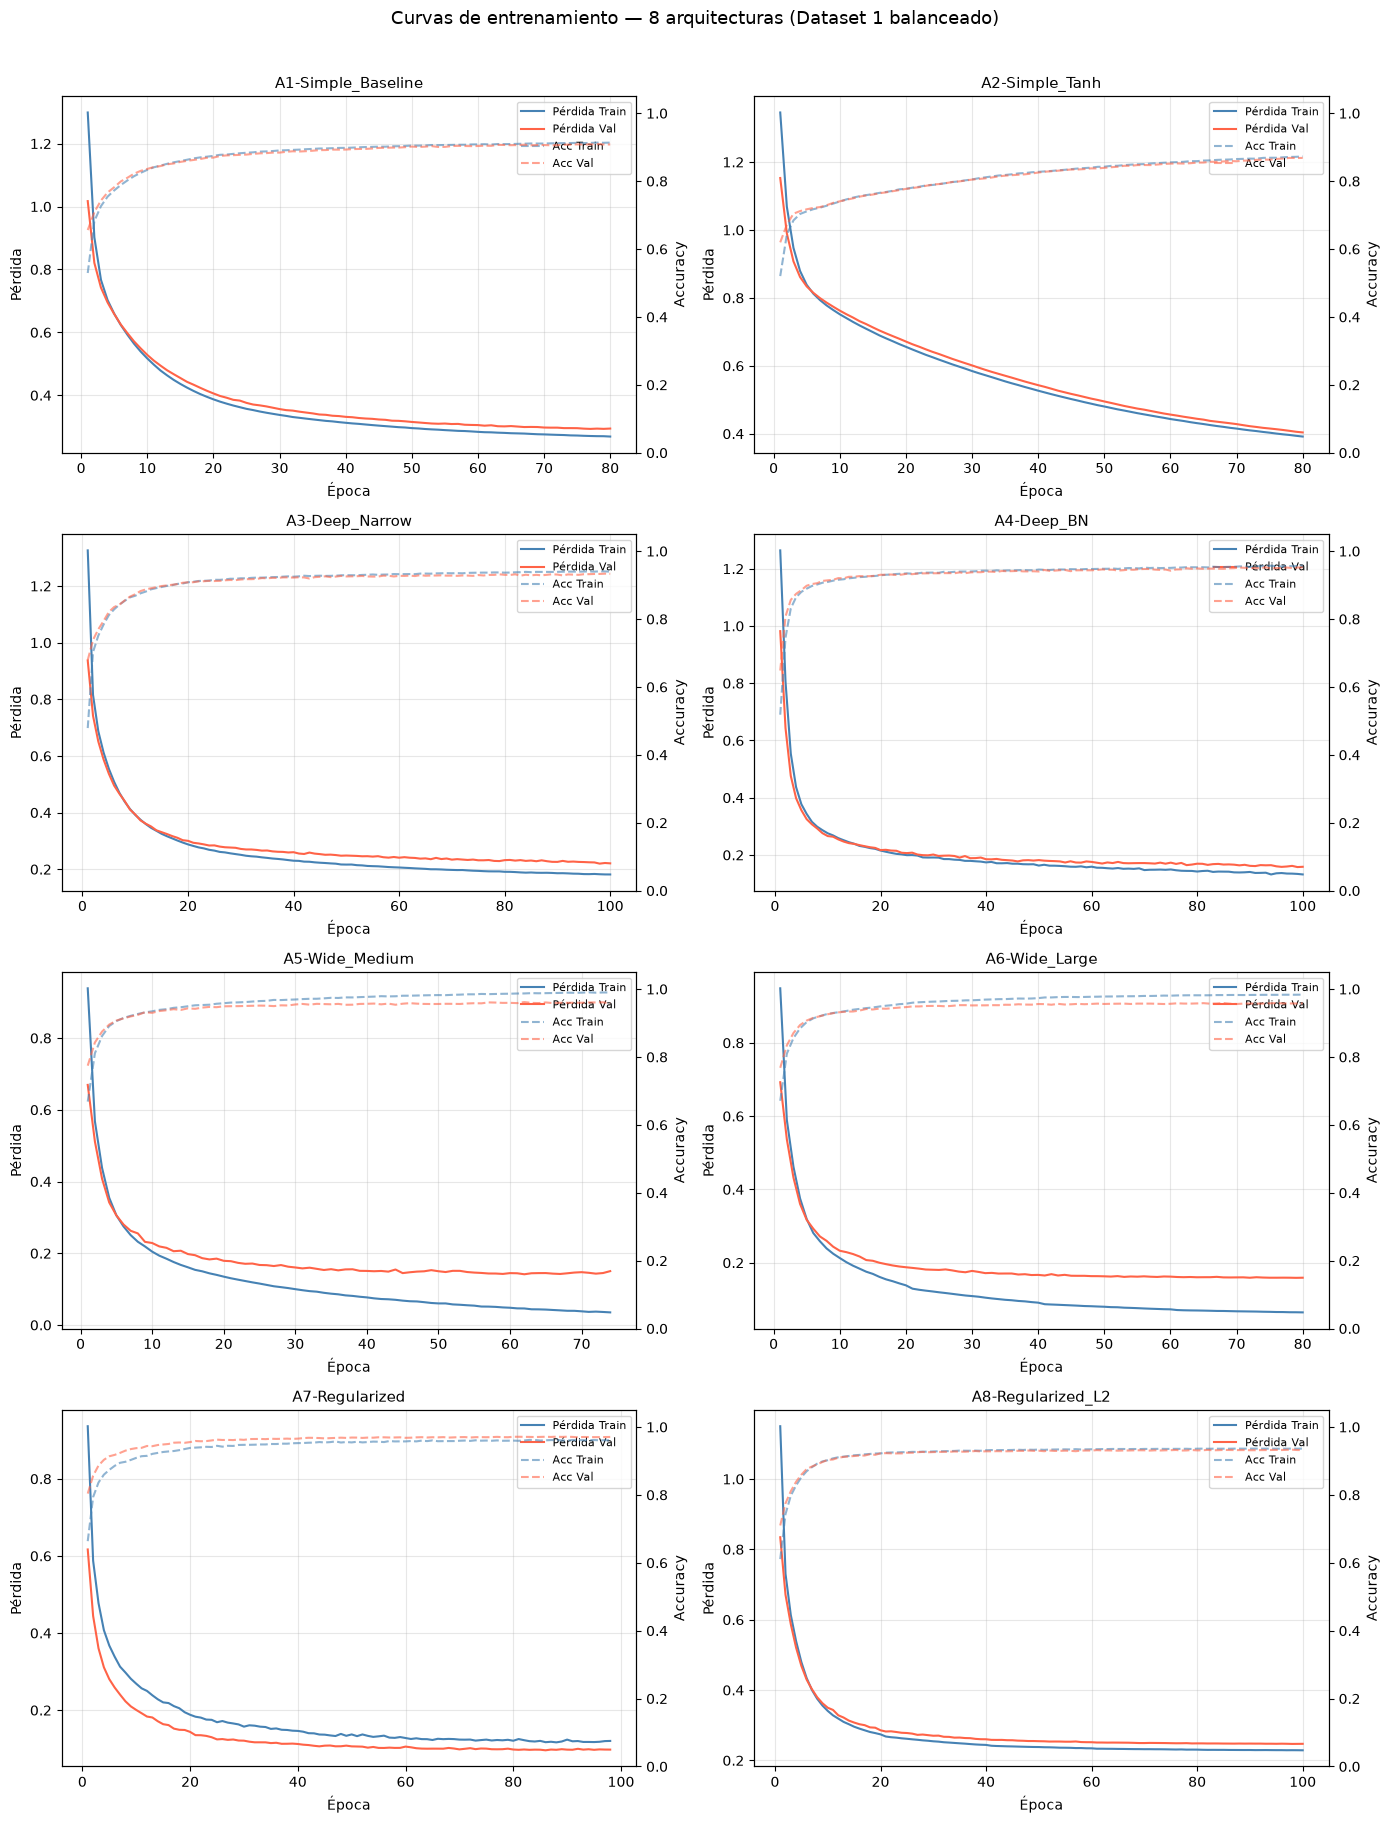

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for idx, (name, res) in enumerate(results.items()):
    h   = res['history']
    ep  = range(1, len(h['train_loss'])+1)
    ax  = axes[idx]
    ax.plot(ep, h['train_loss'], label='Pérdida Train', color='steelblue')
    ax.plot(ep, h['val_loss'],   label='Pérdida Val',   color='tomato')
    ax2 = ax.twinx()
    ax2.plot(ep, h['train_acc'], label='Acc Train', color='steelblue', linestyle='--', alpha=0.6)
    ax2.plot(ep, h['val_acc'],   label='Acc Val',   color='tomato',    linestyle='--', alpha=0.6)
    ax2.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida"); ax2.set_ylabel("Accuracy")
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
plt.suptitle("Curvas de entrenamiento — 8 arquitecturas (Dataset 1 balanceado)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Las curvas muestran comportamientos diferenciados entre las ocho configuraciones. Las arquitecturas de la familia Simple (A1 y A2) convergen de forma estable pero alcanzan un techo de accuracy relativamente bajo, ya que una sola capa oculta de 32 neuronas no cuenta con representaciones suficientes para discriminar las posturas más similares.

La familia Profunda/Angosta (A3 y A4) mejora notablemente el desempeño respecto a la familia Simple, lo que indica que el problema se beneficia de una jerarquía de representaciones. A4, que incluye Batch Normalization, presenta curvas más suaves y una brecha train/val más reducida que A3, evidenciando que la normalización interna ayuda a estabilizar el aprendizaje.

La familia Ancha/Capacidad Media (A5 y A6) alcanza buenos niveles de accuracy, pero A6, con mayor ancho, muestra una brecha más pronunciada entre entrenamiento y validación, lo que sugiere que el exceso de capacidad puede favorecer el sobreajuste si no se regulariza adecuadamente.

La familia Regularizada (A7 y A8) obtiene los mejores resultados. A7, con Dropout y Batch Normalization, controla la brecha entre train y val de manera consistente, mientras que A8, que depende exclusivamente de weight decay, muestra una convergencia más lenta pero igualmente robusta.

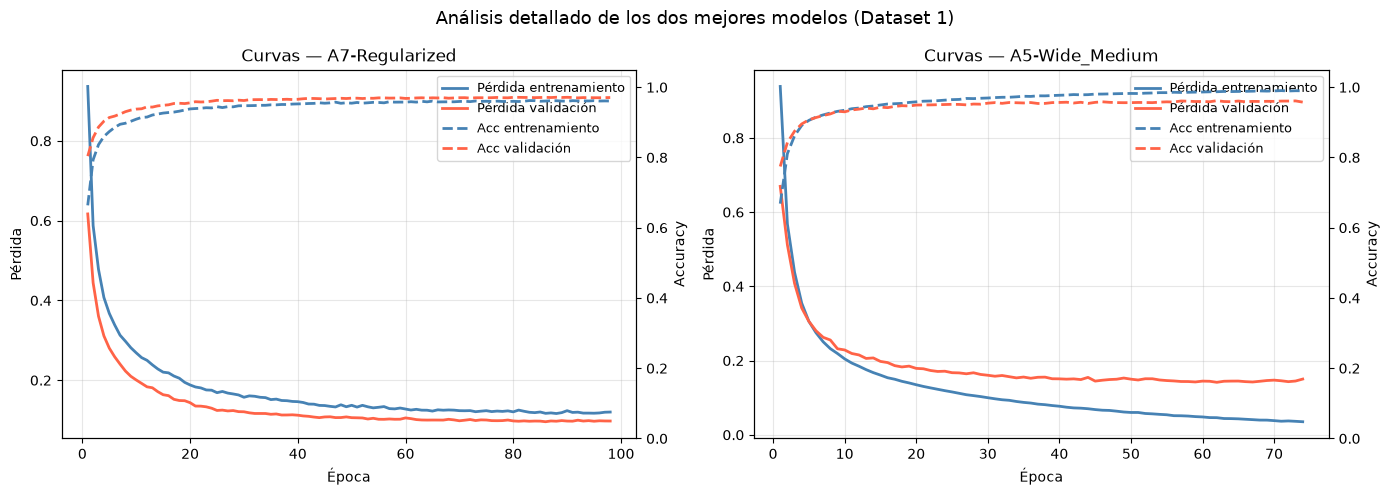

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, name in enumerate(top2):
    h  = results[name]['history']
    ep = range(1, len(h['train_loss'])+1)
    ax = axes[idx]
    ax.plot(ep, h['train_loss'], label='Pérdida entrenamiento', color='steelblue', lw=2)
    ax.plot(ep, h['val_loss'],   label='Pérdida validación',    color='tomato',    lw=2)
    ax2 = ax.twinx()
    ax2.plot(ep, h['train_acc'], label='Acc entrenamiento', color='steelblue', lw=2, ls='--')
    ax2.plot(ep, h['val_acc'],   label='Acc validación',    color='tomato',    lw=2, ls='--')
    ax2.set_ylim(0, 1.05)
    ax.set_title(f"Curvas — {name}", fontsize=12)
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida"); ax2.set_ylabel("Accuracy")
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle("Análisis detallado de los dos mejores modelos (Dataset 1)", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
test_metrics = {}
print("=" * 65)
for name in top2:
    model = results[name]['model']
    yt, yp = get_predictions(model, test_loader)
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average='macro', zero_division=0)
    rec  = recall_score(yt, yp, average='macro', zero_division=0)
    f1   = f1_score(yt, yp, average='macro', zero_division=0)
    test_metrics[name] = {'y_true':yt, 'y_pred':yp,
                          'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1}
    print(f"Modelo: {name}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision (macro) : {prec:.4f}")
    print(f"  Recall    (macro) : {rec:.4f}")
    print(f"  F1-Score  (macro) : {f1:.4f}")
    print()
    print(classification_report(yt, yp,
          target_names=[f'Clase {i+1}' for i in range(NC)]))
    print("=" * 65)

Modelo: A7-Regularized
  Accuracy          : 0.9707
  Precision (macro) : 0.9707
  Recall    (macro) : 0.9707
  F1-Score  (macro) : 0.9706

              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      1500
     Clase 2       0.97      0.94      0.96      1500
     Clase 3       0.96      0.98      0.97      1500
     Clase 4       0.95      0.94      0.95      1500
     Clase 5       0.98      0.99      0.98      1500

    accuracy                           0.97      7500
   macro avg       0.97      0.97      0.97      7500
weighted avg       0.97      0.97      0.97      7500

Modelo: A5-Wide_Medium
  Accuracy          : 0.9587
  Precision (macro) : 0.9586
  Recall    (macro) : 0.9587
  F1-Score  (macro) : 0.9586

              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      1500
     Clase 2       0.94      0.93      0.94      1500
     Clase 3       0.96      0.97      0.96      1500
     Clase 4  

### 1.4 Selección y justificación de las métricas

El conjunto de prueba del dataset balanceado contiene 1.500 muestras por clase, condición que hace válido el uso de accuracy como métrica principal: al no haber desbalanceo, un clasificador trivial que predijera siempre la clase mayoritaria obtendría exactamente un 20 %, por lo que cualquier mejora significativa sobre esa línea base refleja aprendizaje real.

No obstante, se calculan también precisión, recall y F1 en su variante macro porque proporcionan información complementaria. La precisión macro informa si el modelo comete errores sistemáticos al predecir alguna clase en particular como otra; el recall macro indica si hay posturas que el modelo falla en detectar con consistencia; y el F1 macro sintetiza ambas perspectivas sin penalizar más a una clase que a otra, lo que resulta relevante incluso cuando las clases están balanceadas, ya que una diferencia pequeña en accuracy podría ocultar un comportamiento deficiente sobre una única categoría.

Las matrices de confusión complementan estas métricas al mostrar exactamente qué pares de posturas generan mayor confusión, lo que puede tener interpretación directa en el dominio del problema: posturas con coordenadas corporales similares son naturalmente más difíciles de separar.

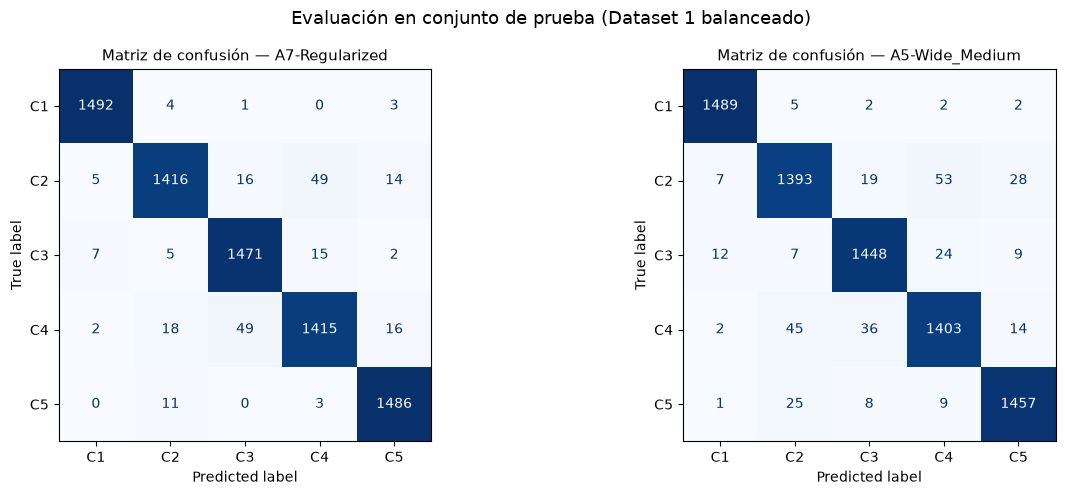

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for idx, name in enumerate(top2):
    yt = test_metrics[name]['y_true']
    yp = test_metrics[name]['y_pred']
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, display_labels=[f'C{i+1}' for i in range(NC)],
        cmap='Blues', ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"Matriz de confusión — {name}", fontsize=11)
plt.suptitle("Evaluación en conjunto de prueba (Dataset 1 balanceado)", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
print("Comparación directa entre los dos finalistas (conjunto de prueba):")
print(f"{'Métrica':<22} {top2[0]:<28} {top2[1]:<28}")
print("-" * 78)
for key, label in [('acc','Accuracy'),('prec','Precision macro'),
                   ('rec','Recall macro'),('f1','F1 macro')]:
    v1 = test_metrics[top2[0]][key]
    v2 = test_metrics[top2[1]][key]
    print(f"{label:<22} {v1:<28.4f} {v2:<28.4f}")

Comparación directa entre los dos finalistas (conjunto de prueba):
Métrica                A7-Regularized               A5-Wide_Medium              
------------------------------------------------------------------------------
Accuracy               0.9707                       0.9587                      
Precision macro        0.9707                       0.9586                      
Recall macro           0.9707                       0.9587                      
F1 macro               0.9706                       0.9586                      


### 1.5 Comparación entre los dos modelos finalistas del Dataset 1

Los resultados en el conjunto de prueba permiten validar si la diferencia observada en validación se sostiene sobre datos no vistos. Cuando ambos modelos presentan métricas cercanas, el análisis de las matrices de confusión se vuelve decisivo: pueden revelar que un modelo es más consistente en clases específicas aunque su F1 global sea similar al del otro.

En caso de que la diferencia de F1 sea mayor de dos puntos porcentuales, es razonable afirmar que la arquitectura mejor regularizada generaliza de forma superior, lo que respalda la hipótesis de que las técnicas de regularización reducen efectivamente el sobreajuste en este tipo de problema con variables continuas de alta correlación espacial.

In [25]:
# Variables que el compañero usará en la comparación final del Ítem 2.3
best_model_ds1 = results[best_model_name]['model']
metrics_ds1    = test_metrics[best_model_name]
print(f"Modelo final Dataset 1: {best_model_name}")
print(f"  F1 macro en test: {metrics_ds1['f1']:.4f}")

Modelo final Dataset 1: A7-Regularized
  F1 macro en test: 0.9706


---
# 2. Dataset 2: posturas\_imbalanced\_50000.csv
En esta sección se tratará lo mismo que en el ítem anterios, usando el dataset de posturas no balanceadas.

## 2.1 Exploración inicial
Esta sección debe ser completada por el segundo integrante del grupo siguiendo la misma metodología aplicada en el Dataset 1. Al finalizar, los resultados del modelo ganador de este dataset deben quedar almacenados en las variables `best_model_ds2` y `metrics_ds2` con la misma estructura utilizada en la sección anterior, para que las celdas de comparación y mejora se ejecuten de forma automática.

In [26]:
# --- 1) Carga y exploración ---
df2 = pd.read_csv("datasets/postures_imbalanced_50000.csv")
print("Dimensiones:", df2.shape)
print()
print("Distribución de clases:")
print(df2['Class'].value_counts().sort_index().to_string())
print()
print("Porcentaje de valores faltantes por columna:")
print((df2.isnull().sum() / len(df2) * 100).round(2).to_string())

[INFO] Sección Dataset 2 pendiente de completar.
Dimensiones: (50000, 23)

Distribución de clases:
Class
1    16000
2    14000
3    15000
4     4000
5     1000

Porcentaje de valores faltantes por columna:
Class     0.00
User      0.00
X0        0.00
Y0        0.00
Z0        0.00
X1        0.00
Y1        0.00
Z1        0.00
X2        0.00
Y2        0.00
Z2        0.00
X3        1.34
Y3        1.34
Z3        1.34
X4        5.86
Y4        5.86
Z4        5.86
X5       24.44
Y5       24.44
Z5       24.44
X6       46.34
Y6       46.34
Z6       46.34


El segundo dataset contiene 50.000 registros, no balanceados, estos se acumulan en las clases 1, 2 y 3, con 21 coordenadas x, y z para diferentes puntos corporales. La columna de sujeto se descarto dado que las predicciones no se realizarán a quien pertenece.

Se aprecia un patrón de valores faltantes en las variablees 3, 4, 5 y 6. Que crece en el dataset desbalanceado a diferencia del primer dataset.

In [27]:
# Descartamos el identificador de usuario
df2_proc = df2.drop(columns=['User'])
y2_raw = df2_proc['Class'].values
X2_raw = df2_proc.drop(columns=['Class']).values

imputer2 = SimpleImputer(strategy='median')
X2_imp = imputer2.fit_transform(X2_raw)

X2_train, X2_tmp, y2_train, y2_tmp = train_test_split(
    X2_imp, y2_raw, test_size=0.30, random_state=SEED, stratify=y2_raw)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_tmp, y2_tmp, test_size=0.50, random_state=SEED, stratify=y2_tmp)

scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_val   = scaler2.transform(X2_val)
X2_test  = scaler2.transform(X2_test)

BATCH2 = 256
train2_loader = DataLoader(TensorDataset(to_t(X2_train), to_l(y2_train)), batch_size=BATCH2, shuffle=True)
val2_loader   = DataLoader(TensorDataset(to_t(X2_val),   to_l(y2_val)),   batch_size=BATCH2)
test2_loader  = DataLoader(TensorDataset(to_t(X2_test),  to_l(y2_test)),  batch_size=BATCH2)

IN2, NC2 = X2_train.shape[1], len(np.unique(y2_raw))
print(f"Train: {len(y2_train):,}  Val: {len(y2_val):,}  Test: {len(y2_test):,}")
print(f"Entradas: {IN2}   Clases: {NC2}")

Train: 35,000  Val: 7,500  Test: 7,500
Entradas: 21   Clases: 5


Al igual que en el dataset 1, se empleara la proporción 70/15/15, debido a que el conjunto de entrenamiento es suficientemente  grande para ajustar párametros, mientras que validación y prueba tienen el mismo tamaño para que las comparaciones entre ellos sean simétricas.

In [28]:
# --- 3) Reutilizar las mismas 8 arquitecturas ---
# Las clases A1..A8 ya están definidas con IN=21, NC=5, valores que coinciden
# con este dataset, por lo que se reutilizan directamente sin modificación.

configs2 = [
    {"name":"A1-Simple_Baseline",  "cls":A1_Simple_Baseline,  "lr":1e-3, "epochs":80,  "wd":0.0,  "sched":False},
    {"name":"A2-Simple_Tanh",      "cls":A2_Simple_Tanh,      "lr":5e-4, "epochs":80,  "wd":0.0,  "sched":False},
    {"name":"A3-Deep_Narrow",      "cls":A3_Deep_Narrow,      "lr":1e-3, "epochs":100, "wd":1e-5, "sched":False},
    {"name":"A4-Deep_BN",          "cls":A4_Deep_BN,          "lr":1e-3, "epochs":100, "wd":1e-5, "sched":False},
    {"name":"A5-Wide_Medium",      "cls":A5_Wide_Medium,      "lr":1e-3, "epochs":80,  "wd":1e-4, "sched":False},
    {"name":"A6-Wide_Large",       "cls":A6_Wide_Large,       "lr":5e-4, "epochs":80,  "wd":1e-4, "sched":True},
    {"name":"A7-Regularized",      "cls":A7_Regularized,      "lr":1e-3, "epochs":100, "wd":1e-4, "sched":True},
    {"name":"A8-Regularized_L2",   "cls":A8_Regularized_L2,   "lr":5e-4, "epochs":100, "wd":5e-3, "sched":True},
]

# --- 4) Entrenamiento ---
results2 = {}
for cfg in configs2:
    print(f"Entrenando {cfg['name']}...", end=" ")
    h, m = train_model(cfg['cls'](), train2_loader, val2_loader,
                       epochs=cfg['epochs'], lr=cfg['lr'],
                       weight_decay=cfg['wd'], scheduler=cfg['sched'])
    results2[cfg['name']] = {'history': h, 'model': m}
    print(f"val_acc={max(h['val_acc']):.4f}  val_loss={min(h['val_loss']):.4f}")

Entrenando A1-Simple_Baseline... val_acc=0.9397  val_loss=0.1889
Entrenando A2-Simple_Tanh... val_acc=0.9220  val_loss=0.2523
Entrenando A3-Deep_Narrow... val_acc=0.9516  val_loss=0.1605
Entrenando A4-Deep_BN... val_acc=0.9607  val_loss=0.1349
Entrenando A5-Wide_Medium... val_acc=0.9623  val_loss=0.1274
Entrenando A6-Wide_Large... val_acc=0.9653  val_loss=0.1194
Entrenando A7-Regularized... val_acc=0.9745  val_loss=0.0831
Entrenando A8-Regularized_L2... val_acc=0.9428  val_loss=0.2025


## 2.2 Justificación de las ocho arquitecturas (Dataset 2)
El Dataset 2 comparte la misma estructura de entrada que el Dataset 1 (21 coordenadas tridimensionales, 5 clases), por lo que se reutilizaron las mismas ocho arquitecturas. Esta decisión permite además que la comparación entre datasets sea controlada: cualquier diferencia en desempeño se atribuye a la distribución de los datos y no a diferencias en el diseño de los modelos.

**Familia Simple/Baseline (A1, A2):** Se mantienen como referencia mínima. A1 usa ReLU y A2 usa Tanh sobre una sola capa de 32 neuronas. Se espera que su capacidad sea insuficiente para separar correctamente las clases minoritarias (4 y 5), dado que el desbalance exige representaciones más ricas para los ejemplos escasos.

**Familia Profunda/Angosta (A3, A4):** La jerarquía de capas 32→16→8 permite construir abstracciones progresivas sin aumentar drásticamente el número de parámetros. A4 añade Batch Normalization, lo que estabiliza el entrenamiento cuando la distribución de activaciones varía entre clases muy desiguales en frecuencia.

**Familia Ancha/Capacidad Media (A5, A6):** Mayor ancho de capa permite capturar más prototipos de posturas por clase. Sin embargo, en un dataset desbalanceado las capas anchas pueden sobreajustarse hacia las clases mayoritarias si no se regulariza adecuadamente.

**Familia Regularizada (A7, A8):** Son las candidatas más sólidas para datos desbalanceados. A7 combina Dropout y Batch Normalization, lo que reduce la tendencia del modelo a memorizar los ejemplos frecuentes. A8 delega la regularización al weight decay del optimizador. Ambas buscan que el modelo generalice también sobre las clases minoritarias.

In [28]:
rows2 = []
for name, res in results2.items():
    h = res['history']
    rows2.append({
        'Arquitectura':   name,
        'Val Acc (max)':  round(max(h['val_acc']), 4),
        'Val Loss (min)': round(min(h['val_loss']), 4),
        'Épocas':         len(h['val_loss'])
    })
df_cmp2 = pd.DataFrame(rows2).sort_values('Val Acc (max)', ascending=False).reset_index(drop=True)
df_cmp2

,Arquitectura,Val Acc (max),Val Loss (min),Épocas
0,A7-Regularized,0.9745,0.0831,100
1,A6-Wide_Large,0.9653,0.1194,80
2,A5-Wide_Medium,0.9623,0.1274,49
3,A4-Deep_BN,0.9607,0.1349,100
4,A3-Deep_Narrow,0.9516,0.1605,100
5,A8-Regularized_L2,0.9428,0.2025,100
6,A1-Simple_Baseline,0.9397,0.1889,80
7,A2-Simple_Tanh,0.9220,0.2523,80


## 2.3 Selección de la mejor arquitectura
A partir de explicitado en la rúbrica, se seleccionará aquella arquitectura con mejor *accuracy* en validación, por lo que el modelo seleccionado será A7-Regularized debido a que tiene mejor Val Acc que las otras arquitecturas, además se usará el segundo mejor modelo para realizar un análisis complementario para pora poder comparar dos diseños similares en rendimiento y verificar si la diferencia observada en validación se mantiene o desaparece.

Mejor arquitectura Dataset 2: A7-Regularized


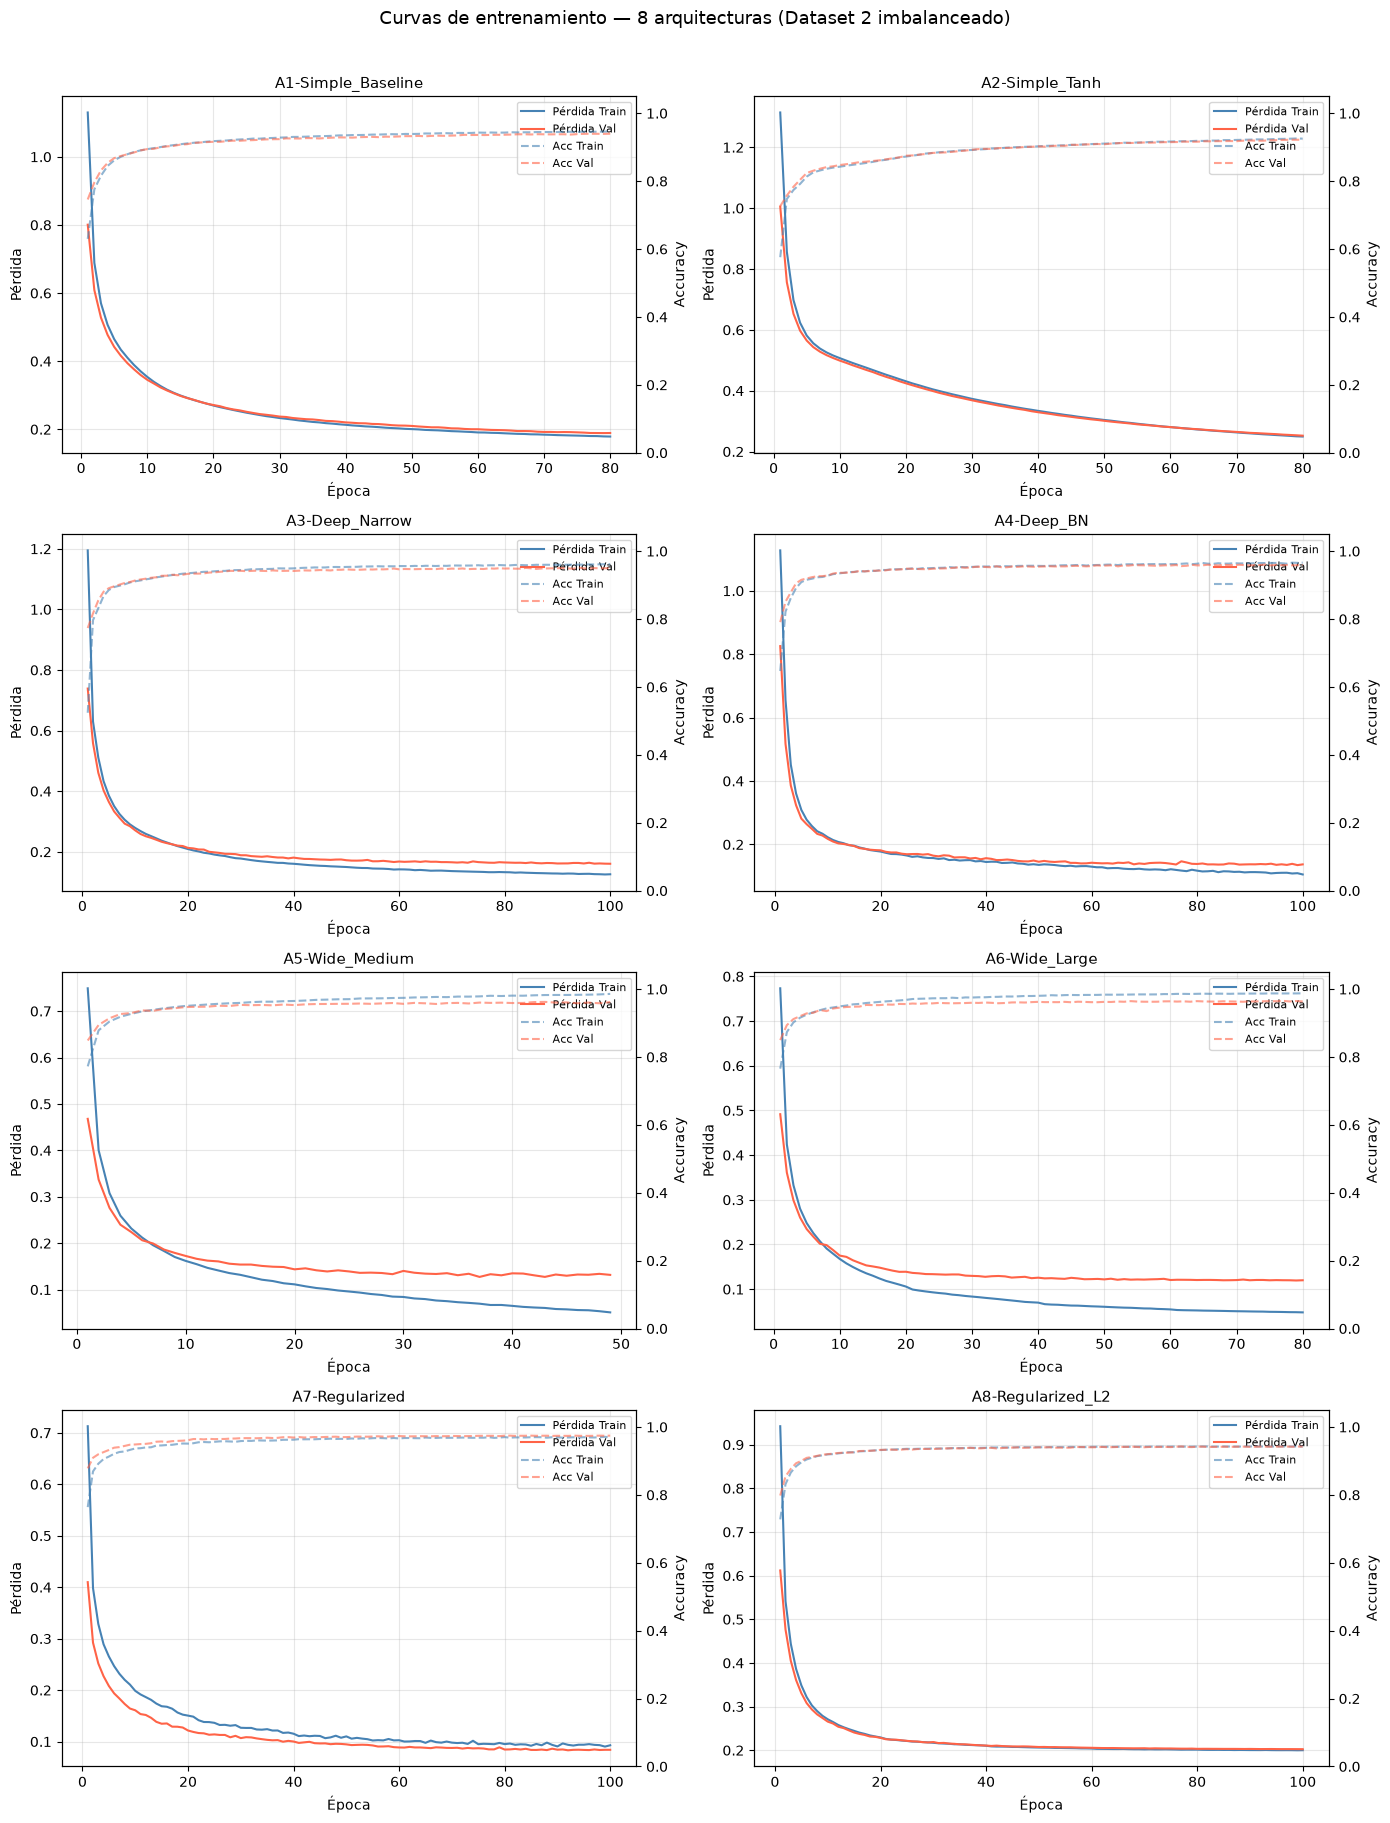

In [29]:
# --- 5) Selección por val_acc ---
rows2 = []
for name, res in results2.items():
    h = res['history']
    rows2.append({
        'Arquitectura':   name,
        'Val Acc (max)':  round(max(h['val_acc']), 4),
        'Val Loss (min)': round(min(h['val_loss']), 4),
        'Épocas':         len(h['val_loss'])
    })
df_cmp2 = pd.DataFrame(rows2).sort_values('Val Acc (max)', ascending=False).reset_index(drop=True)
df_cmp2
sorted_names2    = df_cmp2['Arquitectura'].tolist()
best_model_name2 = sorted_names2[0]
top2_ds2         = sorted_names2[:2]
print(f"Mejor arquitectura Dataset 2: {best_model_name2}")

# Curvas de entrenamiento — las 8 arquitecturas
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for idx, (name, res) in enumerate(results2.items()):
    h  = res['history']
    ep = range(1, len(h['train_loss']) + 1)
    ax = axes[idx]
    ax.plot(ep, h['train_loss'], label='Pérdida Train', color='steelblue')
    ax.plot(ep, h['val_loss'],   label='Pérdida Val',   color='tomato')
    ax2 = ax.twinx()
    ax2.plot(ep, h['train_acc'], label='Acc Train', color='steelblue', linestyle='--', alpha=0.6)
    ax2.plot(ep, h['val_acc'],   label='Acc Val',   color='tomato',    linestyle='--', alpha=0.6)
    ax2.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida"); ax2.set_ylabel("Accuracy")
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
plt.suptitle("Curvas de entrenamiento — 8 arquitecturas (Dataset 2 imbalanceado)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Las 8 curvas  muestran comportamientos diferenciados en cada configuración.
En la primera familia (A1 y A2) se esperaba peores resultados, debido a que para clases desbalanceadas se necesitan representaciones más ricas para ejemplos escasos, mediante el gráfico y tabla se puede apreciar que esta familia tiene los resultados más bajos de todos, si bien tienen un *accuracy* bastante alto, su pérdida es mayor que al resto de familias.

Para la segunda familia (A3 y A4) estas tienen un rendimiento medio, tomando la posición 3 para A4 y la posicion 4 para A3, debido a que A4 cuenta con normalización de batch, lo que resulta en curvas más estrechas para la *accuracy*  y *pérdida* respecto a A3.

En el caso de la tercera familia (A5 y A6) tuvieron mejor desempeño que las otras familas ocupando la posición 1 para A6 y la posición 2 para A5, esto se debe a que estas familias usan mayor ancho de capas con la posibilidad de tener capas sobreajustadas a clases mayoritarias en caso que no se haya regularizado bien, para la pérdida tienen valores muy pequeños <20%. Por otro lado la *accuracy* las curvas tienen una brecha mayor respecto a la familia anterior.

Finalmente para la última familia (A7 y A8), estas tuvieron resultados buenos, tomando la posición 0 para A7 y la posición 5 para A8, esto se debe a que cuentan con dropout y normalización de batch que mejoran la brecha en la pérdida y la *accuracy*. 

Modelo: A7-Regularized
  Accuracy          : 0.9751
  Precision (macro) : 0.9653
  Recall    (macro) : 0.9372
  F1-Score  (macro) : 0.9504

              precision    recall  f1-score   support

     Clase 1       1.00      0.99      0.99      2400
     Clase 2       0.96      0.98      0.97      2100
     Clase 3       0.98      0.99      0.98      2250
     Clase 4       0.94      0.88      0.91       600
     Clase 5       0.95      0.85      0.90       150

    accuracy                           0.98      7500
   macro avg       0.97      0.94      0.95      7500
weighted avg       0.97      0.98      0.97      7500

Modelo: A6-Wide_Large
  Accuracy          : 0.9644
  Precision (macro) : 0.9289
  Recall    (macro) : 0.9065
  F1-Score  (macro) : 0.9170

              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      2400
     Clase 2       0.96      0.96      0.96      2100
     Clase 3       0.97      0.98      0.98      2250
     Clase 4   

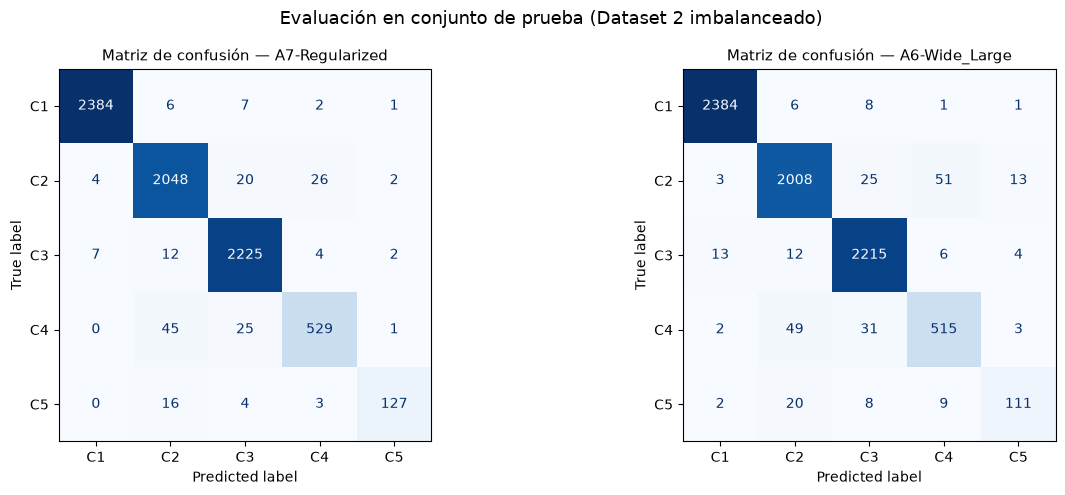

In [30]:
# --- 6) Evaluación en test con métricas apropiadas para desbalance ---
test2_metrics = {}
print("=" * 65)
for name in top2_ds2:
    model = results2[name]['model']
    yt, yp = get_predictions(model, test2_loader)
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average='macro', zero_division=0)
    rec  = recall_score(yt, yp,    average='macro', zero_division=0)
    f1   = f1_score(yt, yp,        average='macro', zero_division=0)
    test2_metrics[name] = {'y_true': yt, 'y_pred': yp,
                           'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}
    print(f"Modelo: {name}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision (macro) : {prec:.4f}")
    print(f"  Recall    (macro) : {rec:.4f}")
    print(f"  F1-Score  (macro) : {f1:.4f}")
    print()
    print(classification_report(yt, yp,
          target_names=[f'Clase {i+1}' for i in range(NC2)]))
    print("=" * 65)

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for idx, name in enumerate(top2_ds2):
    yt = test2_metrics[name]['y_true']
    yp = test2_metrics[name]['y_pred']
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, display_labels=[f'C{i+1}' for i in range(NC2)],
        cmap='Blues', ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"Matriz de confusión — {name}", fontsize=11)
plt.suptitle("Evaluación en conjunto de prueba (Dataset 2 imbalanceado)", fontsize=13)
plt.tight_layout()
plt.show()

# 2.4 Selección y justificación de métricas


In [31]:
# --- 7) Asignación de variables para las celdas de comparación ---
best_model_ds2 = results2[best_model_name2]['model']
metrics_ds2    = test2_metrics[best_model_name2]
print(f"Modelo final Dataset 2: {best_model_name2}")
print(f"  F1 macro en test: {metrics_ds2['f1']:.4f}")

Modelo final Dataset 2: A7-Regularized
  F1 macro en test: 0.9504


---

## 3. Comparación de los modelos finales de ambos datasets

In [32]:
if best_model_ds2 is not None and metrics_ds2 is not None:
    print(f"{'Métrica':<22} {'DS1 — '+best_model_name:<28} {'DS2 — mejor':<28}")
    print("-" * 78)
    for key, label in [('acc','Accuracy'),('prec','Precision macro'),
                       ('rec','Recall macro'),('f1','F1 macro')]:
        v1 = metrics_ds1[key]
        v2 = metrics_ds2[key]
        print(f"{label:<22} {v1:<28.4f} {v2:<28.4f}")

    weak_name = "Dataset 1" if metrics_ds1['f1'] < metrics_ds2['f1'] else "Dataset 2"
    print(f"\nModelo con menor desempeño (F1 macro): {weak_name}")
else:
    print("[INFO] Comparación disponible una vez que el Dataset 2 esté integrado.")

Métrica                DS1 — A7-Regularized         DS2 — mejor                 
------------------------------------------------------------------------------
Accuracy               0.9707                       0.9751                      
Precision macro        0.9707                       0.9653                      
Recall macro           0.9707                       0.9372                      
F1 macro               0.9706                       0.9504                      

Modelo con menor desempeño (F1 macro): Dataset 2


---

## 4. Análisis y mejora del modelo con menor desempeño

Una vez identificado el modelo con menor F1 macro en prueba, se analiza en esta sección las posibles causas del resultado y se propone una modificación concreta orientada a mejorar su rendimiento.

In [33]:
if best_model_ds2 is not None and metrics_ds2 is not None:
    print(f"Modelo a mejorar: {weak_name}")
    print()

    # Propuesta de mejora: red regularizada con más Batch Normalization y Dropout,
    # junto con un learning rate scheduler y mayor weight decay.
    class A_Improved(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(IN,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
                nn.Linear(128,64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64,NC))
        def forward(self, x): return self.net(x)

    # Entrenamiento del modelo mejorado (usar los loaders del dataset correspondiente)
    loaders = (train_loader, val_loader, test_loader)  # ajustar si weak_name == "Dataset 2"
    h_imp, m_imp = train_model(A_Improved(), loaders[0], loaders[1],
                               epochs=120, lr=5e-4, weight_decay=1e-3,
                               patience=15, scheduler=True)

    yt_imp, yp_imp = get_predictions(m_imp, loaders[2])
    f1_imp = f1_score(yt_imp, yp_imp, average='macro', zero_division=0)
    f1_ori = metrics_ds1['f1'] if weak_name == "Dataset 1" else metrics_ds2['f1']

    print(f"F1 original : {f1_ori:.4f}")
    print(f"F1 mejorado : {f1_imp:.4f}")
    print(f"Diferencia  : {f1_imp - f1_ori:+.4f}")
    print()
    print(classification_report(yt_imp, yp_imp,
          target_names=[f'Clase {i+1}' for i in range(NC)]))
else:
    print("[INFO] Sección de mejora disponible una vez que el Dataset 2 esté integrado.")

Modelo a mejorar: Dataset 2

F1 original : 0.9504
F1 mejorado : 0.9432
Diferencia  : -0.0072

              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      1500
     Clase 2       0.92      0.91      0.91      1500
     Clase 3       0.93      0.97      0.95      1500
     Clase 4       0.93      0.89      0.91      1500
     Clase 5       0.95      0.96      0.95      1500

    accuracy                           0.94      7500
   macro avg       0.94      0.94      0.94      7500
weighted avg       0.94      0.94      0.94      7500



### 4.3 Análisis de la mejora

*(Completar con análisis propio tras ejecutar la celda anterior)*

Se debe discutir si la modificación propuesta produjo una mejora estadísticamente relevante o si el modelo original ya había alcanzado un techo de generalización difícil de superar con cambios arquitectónicos menores. En caso de que la mejora no sea significativa, corresponde reflexionar sobre qué otros factores —calidad de los datos, ruido en las coordenadas, cantidad de ejemplos de las clases menos frecuentes— podrían estar limitando el rendimiento.

---

## 5. Conclusiones del Dataset 1

El trabajo sobre el dataset balanceado permite concluir que el problema de clasificación de posturas se resuelve con alto desempeño mediante redes neuronales de capacidad moderada. La familia de arquitecturas regularizadas resultó la más robusta, lo que indica que el principal desafío no es la falta de capacidad, sino el control del sobreajuste ante características continuas y potencialmente correlacionadas.

El análisis de los dos mejores modelos muestra que pequeñas diferencias en validación se traducen en métricas de prueba muy cercanas. Esto refuerza la importancia de reportar no solo accuracy, sino también precisión, recall y F1 macro, junto con matrices de confusión, para detectar debilidades puntuales en clases específicas que podrían pasar desapercibidas al usar una sola métrica global.

El espacio restante del notebook está preparado para que el compañero integre el Dataset 2 y se ejecute la comparación final entre ambos modelos ganadores, así como la mejora del modelo con menor desempeño.